In [ ]:
#notebooks\02_model_training

# Huấn luyện Mô hình Phân lớp Khách hàng Tiềm năng (Classification)
**Thực hiện:** Thành viên C & Thành viên D  
**Mục tiêu:** Xây dựng hệ thống phân loại khách hàng VIP (High-value customers) dựa trên hành vi mua sắm. So sánh 3 cách tiếp cận:
1. Baseline (Logistic Regression)
2. Mô hình chuẩn (Random Forest)
3. Mô hình nâng cao (XGBoost)

In [2]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# Thư viện Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import xgboost as xgb

# Cấu hình hiển thị
%matplotlib inline
sns.set_theme(style="whitegrid")

# Khắc phục lỗi đường dẫn tự động
current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir) if 'notebooks' in current_dir else current_dir

# Load dữ liệu đặc trưng đã xử lý ở bước trước
data_path = os.path.join(base_dir, 'data', 'processed', 'customer_features.csv')
print(f"Đang đọc dữ liệu từ: {data_path}")
df = pd.read_csv(data_path)
df.head()

Đang đọc dữ liệu từ: d:\CDIO\mobile-clv-prediction\data\processed\customer_features.csv


,customer_id,Recency,Frequency,Monetary,Installment_Rate,Flagship_Ratio,Accessories_Ratio,Favorite_Brand
0,CUS0001,124,3,56990000,0.667,0.667,0.333,Xiaomi
1,CUS0002,111,13,139000000,0.286,0.154,0.385,Samsung
2,CUS0003,95,14,207800000,0.267,0.286,0.357,Samsung
3,CUS0004,18,4,64000000,0.000,0.250,0.500,Samsung
4,CUS0005,57,3,53500000,0.333,0.333,0.333,Apple


## 1. Chuẩn bị Dữ liệu & Tạo Biến Mục tiêu (Target Variable)
Để bài toán trở thành **Học có giám sát (Supervised Learning)**, ta cần một "Nhãn" (Label/Target). 
**Giả định kinh doanh:** Khách hàng VIP (Target = 1) là những người thuộc top 25% chi tiêu nhiều nhất (Monetary) **HOẶC** mua hàng thường xuyên (Frequency > mức trung bình).

Phân phối nhãn (Target):
Is_VIP
0    61.045131
1    38.954869
Name: proportion, dtype: float64


d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


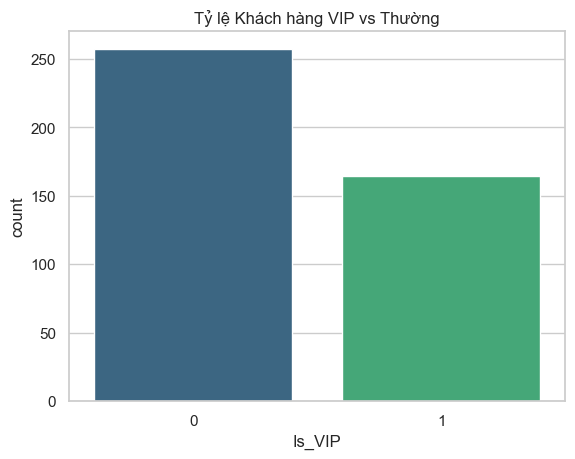

In [3]:
# Xác định ngưỡng VIP
monetary_75th = df['Monetary'].quantile(0.75)
freq_mean = df['Frequency'].mean()

# Tạo cột Target: 1 là VIP, 0 là Thường
df['Is_VIP'] = np.where((df['Monetary'] >= monetary_75th) | (df['Frequency'] > freq_mean), 1, 0)

print("Phân phối nhãn (Target):")
print(df['Is_VIP'].value_counts(normalize=True) * 100)

# Trực quan hóa tỷ lệ mất cân bằng (Imbalance)
sns.countplot(x='Is_VIP', data=df, palette='viridis')
plt.title("Tỷ lệ Khách hàng VIP vs Thường")
plt.show()

## 2. Tiền xử lý dữ liệu (Data Preprocessing)
1. **Encoding:** Chuyển cột `Favorite_Brand` (dạng chữ) thành dạng số (One-Hot Encoding).
2. **Train/Test Split:** Chia dữ liệu thành tập Huấn luyện (80%) và tập Kiểm tra (20%).
3. **Scaling:** Chuẩn hóa các biến liên tục (như Recency, Monetary) về cùng một thang đo.

In [4]:
# Bỏ cột customer_id vì không có giá trị dự đoán
X = df.drop(['customer_id', 'Is_VIP'], axis=1)
y = df['Is_VIP']

# Mã hóa biến phân loại (Categorical variables)
X = pd.get_dummies(X, columns=['Favorite_Brand'], drop_first=True)

# Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (336, 9)
Kích thước tập Test: (85, 9)


## 3. Xây dựng và So sánh Mô hình
Theo yêu cầu đồ án mục 2.4, ta sẽ đánh giá lần lượt 3 mô hình. Hàm dưới đây giúp tự động hóa việc in kết quả.

--- Đánh giá mô hình: Logistic Regression (Baseline) ---
Accuracy: 0.9882 | ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        52
           1       0.97      1.00      0.99        33

    accuracy                           0.99        85
   macro avg       0.99      0.99      0.99        85
weighted avg       0.99      0.99      0.99        85



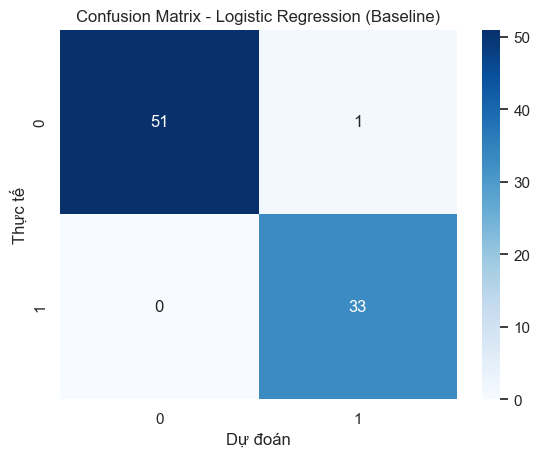

In [5]:
# Khởi tạo Dictionary để lưu kết quả cấu hình
results = {}

def evaluate_model(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    results[model_name] = {'Accuracy': acc, 'ROC_AUC': roc_auc}
    
    print(f"--- Đánh giá mô hình: {model_name} ---")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {roc_auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()

# ---------------------------------------------------------
# Mô hình 1: Baseline (Logistic Regression)
# ---------------------------------------------------------
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Logistic Regression (Baseline)", y_test, y_pred_lr, y_prob_lr)

--- Đánh giá mô hình: Random Forest ---
Accuracy: 1.0000 | ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        33

    accuracy                           1.00        85
   macro avg       1.00      1.00      1.00        85
weighted avg       1.00      1.00      1.00        85



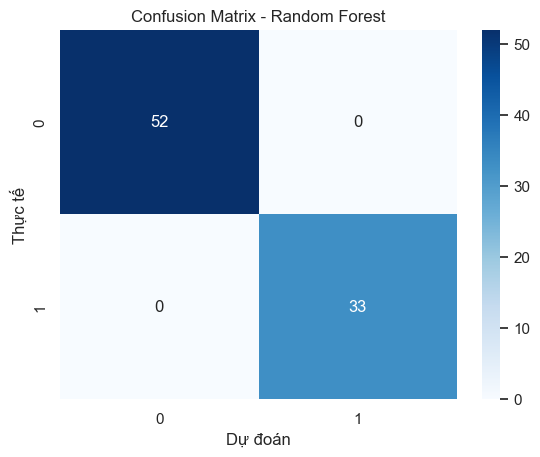

In [6]:
# ---------------------------------------------------------
# Mô hình 2: Standard ML (Random Forest)
# ---------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train) # Tree-based không cần Scaled data

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)

d:\CDIO\.venv\lib\site-packages\xgboost\data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
d:\CDIO\.venv\lib\site-packages\xgboost\data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
d:\CDIO\.venv\lib\site-packages\xgboost\data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
d:\CDIO\.venv\lib\site-packages\xgboost\data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return is_int or is_bool or is_float or is_categorical_dtype(dtype)
d:\CDIO\.venv\lib\site-packages\xgboost\data.py:440: Fu

--- Đánh giá mô hình: XGBoost ---
Accuracy: 1.0000 | ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        33

    accuracy                           1.00        85
   macro avg       1.00      1.00      1.00        85
weighted avg       1.00      1.00      1.00        85



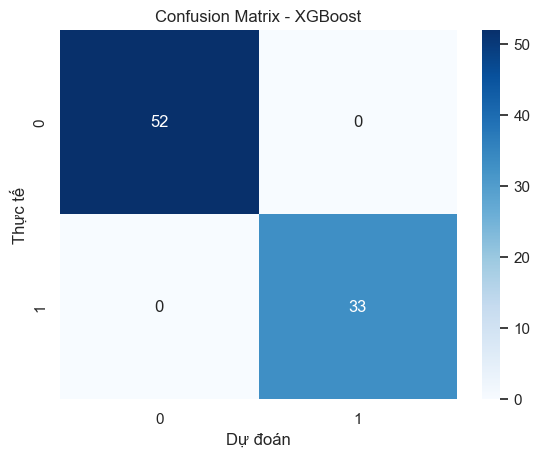

In [7]:
# ---------------------------------------------------------
# Mô hình 3: Advanced ML (XGBoost)
# ---------------------------------------------------------
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)

## 4. Phân tích Kết quả (Mục 2.6 của Đồ án)
So sánh đường cong ROC (ROC Curve) để xem mô hình nào phân tách 2 lớp (VIP vs Thường) tốt nhất. 
Trích xuất **Feature Importance** (Tầm quan trọng của đặc trưng) để giải thích cho doanh nghiệp yếu tố nào quyết định một khách hàng là VIP.

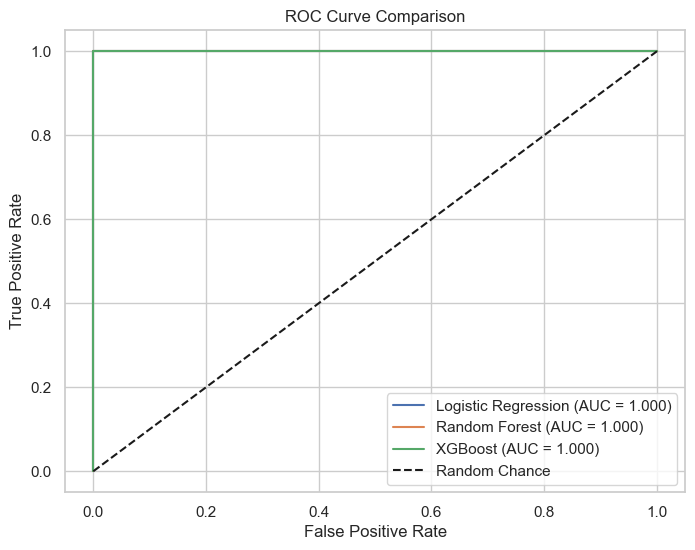

d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


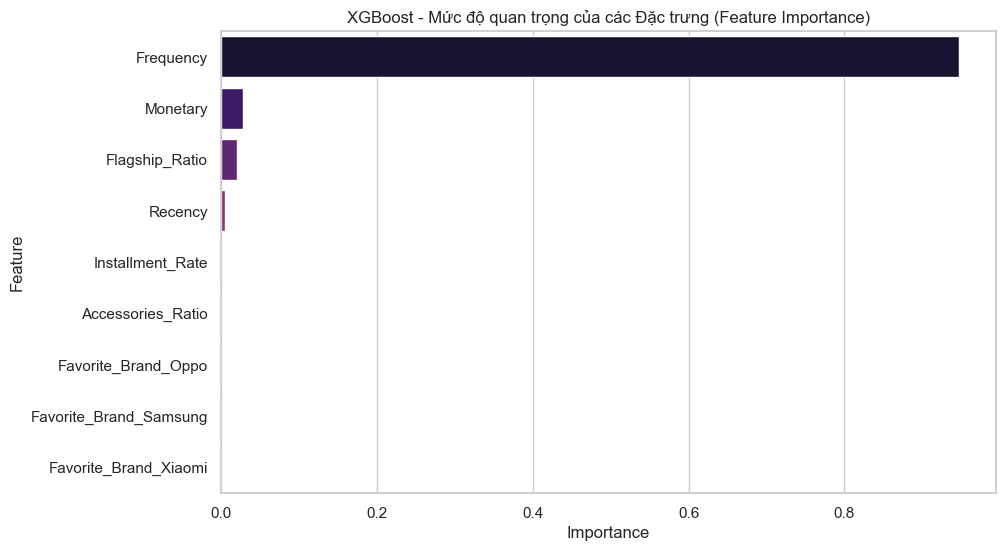

In [8]:
# 1. Vẽ ROC Curve so sánh
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {results['Logistic Regression (Baseline)']['ROC_AUC']:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {results['Random Forest']['ROC_AUC']:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {results['XGBoost']['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# 2. Vẽ Feature Importance từ XGBoost
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='magma')
plt.title('XGBoost - Mức độ quan trọng của các Đặc trưng (Feature Importance)')
plt.show()

## 5. Đóng gói & Lưu Mô hình (Mục 2.7)
Sau khi đánh giá, ta chọn mô hình tốt nhất (thường là XGBoost hoặc Random Forest) và lưu lại cùng với bộ `Scaler` để phục vụ cho ứng dụng Demo (Streamlit) ở tuần sau.

In [9]:
# Đảm bảo thư mục models/ tồn tại
models_dir = os.path.join(base_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

# Lưu mô hình Random Forest (hoặc XGBoost tùy kết quả của bạn) và Scaler
joblib.dump(xgb_model, os.path.join(models_dir, 'best_xgb_model.pkl'))
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))

# Lưu lại danh sách các cột đặc trưng để dùng lúc predict
joblib.dump(list(X.columns), os.path.join(models_dir, 'feature_columns.pkl'))

print("✅ Đã lưu mô hình và Scaler thành công vào thư mục models/ !")

✅ Đã lưu mô hình và Scaler thành công vào thư mục models/ !
